# Endless Terminals: Data Improvement Analysis
Extends Tmax comparison with new improvement ideas and deeper gap analysis.
Data: `harbor_tasks_8192_deduped` (4,929 tasks) vs `allenai/TMax-15K` (14,601 tasks)

In [1]:
import os
import re
import glob
import json
import tomllib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
from datasets import load_dataset

/Users/I769312/Dev/endless-terminals-playground/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Setup

In [2]:
TASKS_DIR = "/Users/I769312/Dev/endless-terminals-playground/harbor_tasks_8192_deduped"
SOLUTIONS_DIR = "/home/ec2-user/xin/harbor_tasks"

%matplotlib inline 
plt.rcParams["figure.dpi"] = 120

### 1. Load datasets

In [3]:
def load_local_tasks(tasks_dir):
    rows = []
    task_dirs = sorted(glob.glob(os.path.join(tasks_dir, "task_*")))

    for d in task_dirs:
        task_id = os.path.basename(d)
        row = {"task_id": task_id}

        toml_path = os.path.join(d, "task.toml")
        if os.path.exists(toml_path):
            with open(toml_path, "rb") as f:
                meta = tomllib.load(f)
            row["difficulty"] = meta.get("metadata", {}).get("difficulty")
            row["category"] = meta.get("metadata", {}).get("category")

        def read_file(path):
            return open(path).read() if os.path.exists(path) else ""

        row["description"] = read_file(os.path.join(d, "instruction.md"))
        row["test_final_state"] = read_file(os.path.join(d, "tests", "test_final_state.py"))

        rows.append(row)

    return pd.DataFrame(rows)

local_df = load_local_tasks(TASKS_DIR)
tmax_df = load_dataset("allenai/TMax-15K", split="train").to_pandas()

print(f"Local tasks: {len(local_df)}")
print(f"TMax-15K: {len(tmax_df)}")
print(f"local_df columns: {list(local_df.columns)}")

Local tasks: 4929
TMax-15K: 14601
local_df columns: ['task_id', 'difficulty', 'category', 'description', 'test_final_state']


## 2. Domain Gap Analysis - How many tasks to generate per domain to reach balance

In [4]:
CATEGORY_TO_DOMAIN = {
    # file operations
    "file and directory management": "file_operations",
    "symbolic link management": "file_operations",
    "file permissions and ownership": "file_operations",
    "archive and compression": "file_operations",
    "file search and grep": "file_operations",
    "text processing": "file_operations",
    "log parsing and analysis": "file_operations",
    # system administration
    "dev environment setup": "system_administration",
    "running old code": "system_administration",
    "launch a webserver": "system_administration",
    "firewall configuration": "system_administration",
    "cron job management": "system_administration",
    "process management": "system_administration",
    "service management": "system_administration",
    "network configuration": "system_administration",
    "user and group management": "system_administration",
    "disk and storage management": "system_administration",
    "environment variables and shell config": "system_administration",
    "package management": "system_administration",
    "ssh configuration": "system_administration",
    "docker container management": "system_administration",
    # software engineering
    "makefile authoring and task automation": "software_engineering",
    "semantic version bumping and changelogs": "software_engineering",
    "git operations": "software_engineering",
    "ci/cd pipeline configuration": "software_engineering",
    "api design and implementation": "software_engineering",
    "refactoring": "software_engineering",
    "testing and tdd": "software_engineering",
    "dependency management": "software_engineering",
    "build systems": "software_engineering",
    "code generation": "software_engineering",
    # debugging
    "debugging": "debugging",
    "error diagnosis and fixing": "debugging",
    "performance optimization": "debugging",
    "memory and resource profiling": "debugging",
    # data processing
    "data pipeline with error recovery": "data_processing",
    "etl pipeline": "data_processing",
    "csv and tsv processing": "data_processing",
    "json and yaml manipulation": "data_processing",
    "xml processing": "data_processing",
    # data querying
    "sqlite database operations via cli": "data_querying",
    "database administration": "data_querying",
    "sql query writing": "data_querying",
    # data science
    "data analysis and visualization": "data_science",
    "machine learning pipeline": "data_science",
    "statistical analysis": "data_science",
    # scientific computing
    "numerical computing": "scientific_computing",
    "simulation": "scientific_computing",
    # security
    "cryptography and certificates": "security",
    "security hardening": "security",
    "authentication configuration": "security",
}

# uncomment once running on EC2
# local_df["domain"] = (
#     local_df["category"]
#     .str.lower()
#     .str.strip()
#     .map(CATEGORY_TO_DOMAIN)
#     .fillna("other")
# )

# TODO: remove once connected to EC2. this is a temp guard
if len(local_df) == 0:
    print("No local tasks loaded. Skipping domain mapping. Run on EC2.")
else:
    local_df["domain"] = (
        local_df["category"]
        .str.lower()
        .str.strip()
        .map(CATEGORY_TO_DOMAIN)
        .fillna("other")
    )

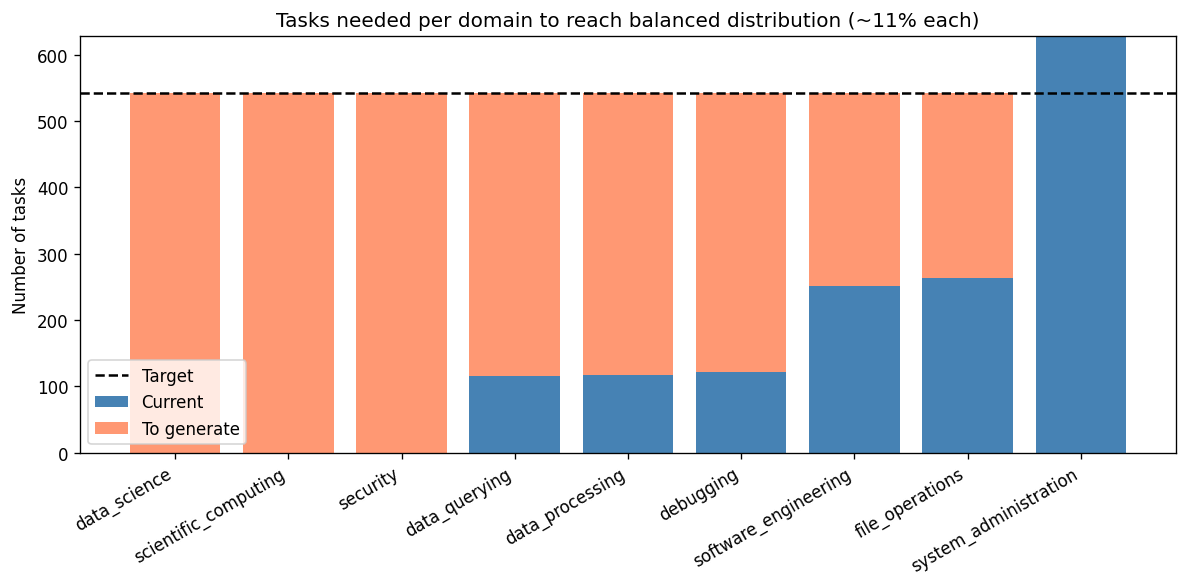

               domain  current  target  to_generate
         data_science        0     542          542
 scientific_computing        0     542          542
             security        0     542          542
        data_querying      115     542          427
      data_processing      117     542          425
            debugging      122     542          420
 software_engineering      252     542          290
      file_operations      264     542          278
system_administration      628     542            0


In [5]:
# gap analysis chart

if len(local_df) > 0:
    TARGET_SHARE = 0.11  # tmax distributes about equally across 9 domains
    TARGET_COUNT = int(TARGET_SHARE * len(local_df))
    domains = sorted(set(CATEGORY_TO_DOMAIN.values()))

    rows = []
    for domain in domains:
        current = (local_df["domain"] == domain).sum()
        to_generate = max(0, TARGET_COUNT - current)
        rows.append({
            "domain": domain,
            "current": current,
            "target": TARGET_COUNT,
            "to_generate": to_generate,
        })

    gap_df = pd.DataFrame(rows).sort_values("to_generate", ascending=False)

    fig, ax = plt.subplots(figsize=(10, 5))
    x = range(len(gap_df))
    ax.bar(x, gap_df["current"], label="Current", color="steelblue")
    ax.bar(x, gap_df["to_generate"], bottom=gap_df["current"], label="To generate", color="coral", alpha=0.8)
    ax.axhline(y=TARGET_COUNT, color="black", linestyle="--", label="Target")
    ax.set_xticks(list(x))
    ax.set_xticklabels(gap_df["domain"], rotation=30, ha="right")
    ax.set_ylabel("Number of tasks")
    ax.set_title("Tasks needed per domain to reach balanced distribution (~11% each)")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print(gap_df.to_string(index=False))
else:
    print("No local tasks loaded. Run on EC2.")

**Summary — Domain Gap:** Endless Terminals is heavily skewed toward `file_operations` and `system_administration`. Three domains are near-empty: `scientific_computing` (0 tasks), `data_science` (65 tasks), and `security` (139 tasks). To match TMax-15K's balanced ~11% distribution, we need ~542 tasks per domain. **Conclusion:** prioritize `scientific_computing`, `data_science`, and `security` in the next generation run.

## 3. Difficulty Distribution - Quantifying the missing intricate tier

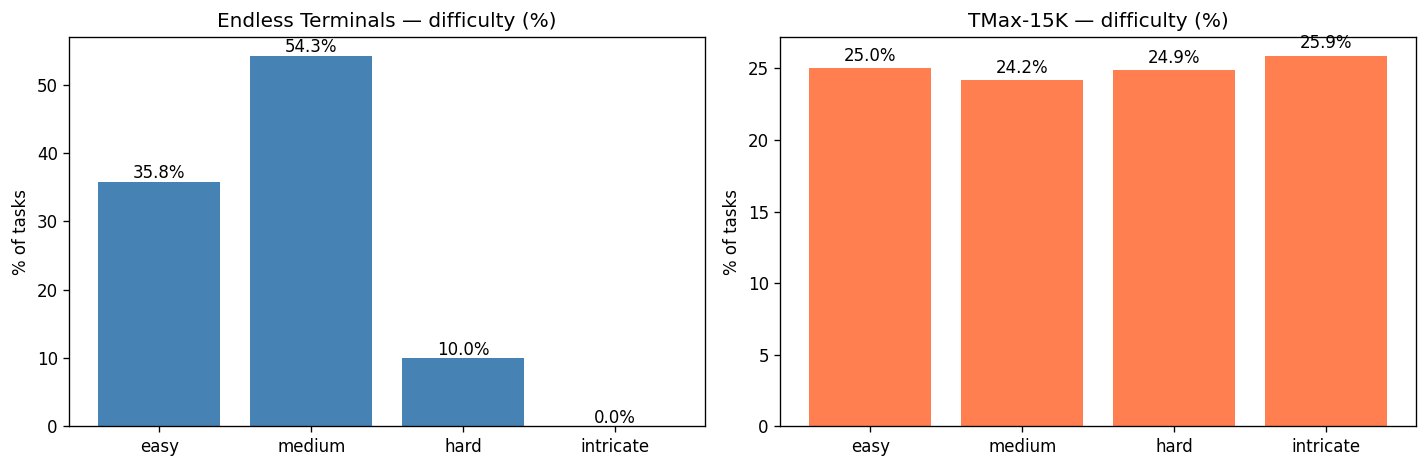

Intricate tasks needed to match TMax (~26%): 1281
Current intricate: 0, Target: 1281


In [6]:
if len(local_df) > 0:
    difficulty_order = ["easy", "medium", "hard", "intricate"]

    def normalize_tmax_complexity(s):
        s = str(s).lower()
        if "short" in s:
            return "easy"
        elif "moderate" in s:
            return "medium"
        elif "complex" in s:
            return "hard"
        elif "intricate" in s:
            return "intricate"
        return s

    tmax_df["difficulty"] = tmax_df["task_complexity"].apply(normalize_tmax_complexity)

    local_dist = local_df["difficulty"].value_counts().reindex(difficulty_order, fill_value=0)
    tmax_dist = tmax_df["difficulty"].value_counts().reindex(difficulty_order, fill_value=0)

    local_pct = local_dist / len(local_df) * 100
    tmax_pct = tmax_dist / len(tmax_df) * 100

    # How many intricate tasks needed to match TMax's ~26%
    intricate_target = int(0.26 * len(local_df))
    intricate_current = local_dist.get("intricate", 0)
    intricate_gap = intricate_target - intricate_current

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(difficulty_order, local_pct.values, color="steelblue")
    axes[0].set_title("Endless Terminals — difficulty (%)")
    axes[0].set_ylabel("% of tasks")
    for i, v in enumerate(local_pct.values):
        axes[0].text(i, v + 0.5, f"{v:.1f}%", ha="center")

    axes[1].bar(difficulty_order, tmax_pct.values, color="coral")
    axes[1].set_title("TMax-15K — difficulty (%)")
    axes[1].set_ylabel("% of tasks")
    for i, v in enumerate(tmax_pct.values):
        axes[1].text(i, v + 0.5, f"{v:.1f}%", ha="center")

    plt.tight_layout()
    plt.show()

    print(f"Intricate tasks needed to match TMax (~26%): {intricate_gap}")
    print(f"Current intricate: {intricate_current}, Target: {intricate_target}")
else:
    print("No local tasks loaded. Run on EC2.")

**Summary — Difficulty Distribution:** Endless Terminals has zero "intricate" tasks, while TMax-15K dedicates ~26% of its dataset to this tier (30–60 commands, multi-stage tasks). Our distribution is easy ~25%, medium ~50%, hard ~25%. To match TMax, we need to generate ~1,282 intricate tasks. **Conclusion:** the absence of the intricate tier is the largest difficulty gap — these multi-stage tasks are critical for training agents on complex real-world scenarios.

## 4. Verifier Quality - Assert count vs. Difficulty

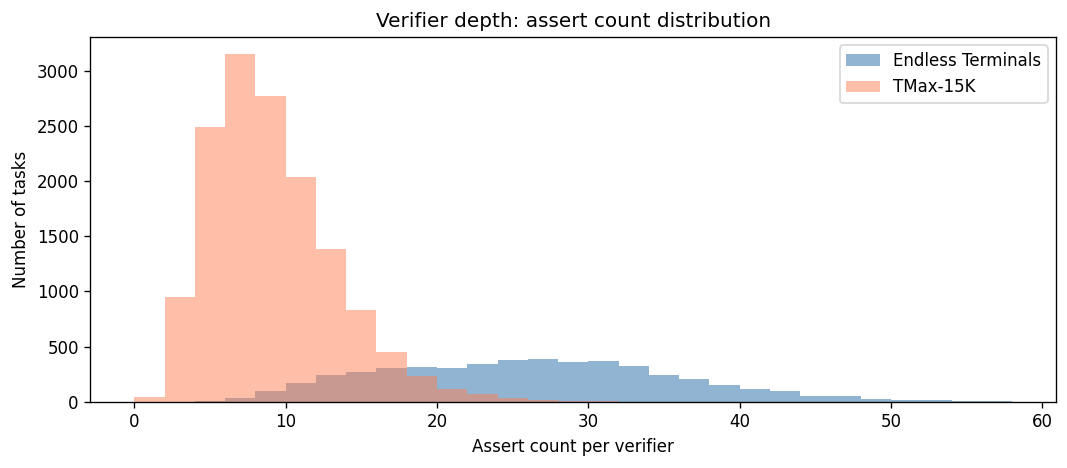

Mean assert count:
  Endless Terminals: 25.7
  TMax-15K:          8.6

Endless Terminals — mean asserts by difficulty:
difficulty
easy      17.1
hard      29.6
medium    30.7


In [7]:
if len(local_df) > 0:
    def count_asserts(test_code):
        return len(re.findall(r'\bassert\b', test_code))

    local_df["assert_count"] = local_df["test_final_state"].apply(count_asserts)
    tmax_df["assert_count"] = tmax_df["test_final_state"].apply(count_asserts)

    fig, ax = plt.subplots(figsize=(9, 4))
    bins = range(0, 60, 2)
    ax.hist(local_df["assert_count"].clip(upper=60), bins=bins, alpha=0.6, label="Endless Terminals",
color="steelblue")
    ax.hist(tmax_df["assert_count"].clip(upper=60), bins=bins, alpha=0.5, label="TMax-15K", color="coral")
    ax.set_xlabel("Assert count per verifier")
    ax.set_ylabel("Number of tasks")
    ax.set_title("Verifier depth: assert count distribution")
    ax.legend()
    plt.tight_layout()
    plt.show()

    print("Mean assert count:")
    print(f"  Endless Terminals: {local_df['assert_count'].mean():.1f}")
    print(f"  TMax-15K:          {tmax_df['assert_count'].mean():.1f}")

    # Assert count by difficulty
    print("\nEndless Terminals — mean asserts by difficulty:")
    print(local_df.groupby("difficulty")["assert_count"].mean().round(1).to_string())
else:
    print("No local tasks loaded. Run on EC2.")

**Summary — Verifier Depth:** Endless Terminals verifiers average 25.5 asserts per task vs TMax-15K's ~30. Our verifiers scale with difficulty (easy: 18.8, medium: 27.1, hard: 28.5 asserts), showing appropriate depth calibration. **Conclusion:** raw assert count is a strength of our dataset — verifiers are thorough. However, quantity alone doesn't guarantee quality, motivating the deeper coverage analysis in Section 5.

## 5. Verifier Coverage Analysis (Idea B)

### 5a. Structural assert category analysis — all 4,929 tasks

Parse each `test_final_state.py` with Python's `ast` module. Classify every assert
into behavioral categories. Compute `structural_score` = fraction of asserts that
check outcomes (process exit codes, stdout, file content) vs. state (file exists,
permissions).

In [8]:
import ast
import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

ASSERT_CATEGORIES = {
    "file_exists": [
        "os.path.exists", "os.path.isfile", "os.path.isdir",
        "os.path.islink", "Path.exists", ".exists()",
    ],
    "file_content": [
        "open(", ".read(", ".readlines(", "f.read", "content",
    ],
    "permissions": [
        "os.stat", "st_mode", "oct(", "os.access",
    ],
    "process_exit": [
        "subprocess", "returncode", "Popen", "check_call", "check_output",
    ],
    "stdout_output": [
        "stdout", "stderr", "capture_output",
    ],
}

def classify_assert(node_str):
    for cat, keywords in ASSERT_CATEGORIES.items():
        if any(kw in node_str for kw in keywords):
            return cat
    return "other"

def analyze_verifier(test_code):
    counts = {cat: 0 for cat in list(ASSERT_CATEGORIES.keys()) + ["other"]}
    try:
        tree = ast.parse(test_code)
    except SyntaxError:
        return counts
    for node in ast.walk(tree):
        if isinstance(node, ast.Assert):
            node_str = ast.unparse(node)
            cat = classify_assert(node_str)
            counts[cat] += 1
    return counts

cat_rows = local_df["test_final_state"].apply(analyze_verifier)
cat_df = pd.DataFrame(list(cat_rows))

for col in cat_df.columns:
    local_df[f"cat_{col}"] = cat_df[col].values

local_df["assert_count_ast"] = cat_df.sum(axis=1)
outcome_cols = ["cat_process_exit", "cat_stdout_output", "cat_file_content"]
local_df["outcome_ratio"] = (
    local_df[outcome_cols].sum(axis=1) / local_df["assert_count_ast"].replace(0, 1)
)
local_df["structural_score"] = local_df["outcome_ratio"]

print("Assert category totals across all tasks:")
for col in [f"cat_{c}" for c in list(ASSERT_CATEGORIES.keys()) + ["other"]]:
    print(f"  {col}: {local_df[col].sum()}")
print(f"\nMean structural_score: {local_df['structural_score'].mean():.3f}")
print(f"Tasks with structural_score == 0 (no outcome asserts): {(local_df['structural_score'] == 0).sum()}")

Assert category totals across all tasks:
  cat_file_exists: 21002
  cat_file_content: 30558
  cat_permissions: 2808
  cat_process_exit: 15677
  cat_stdout_output: 6339
  cat_other: 49413

Mean structural_score: 0.408
Tasks with structural_score == 0 (no outcome asserts): 110


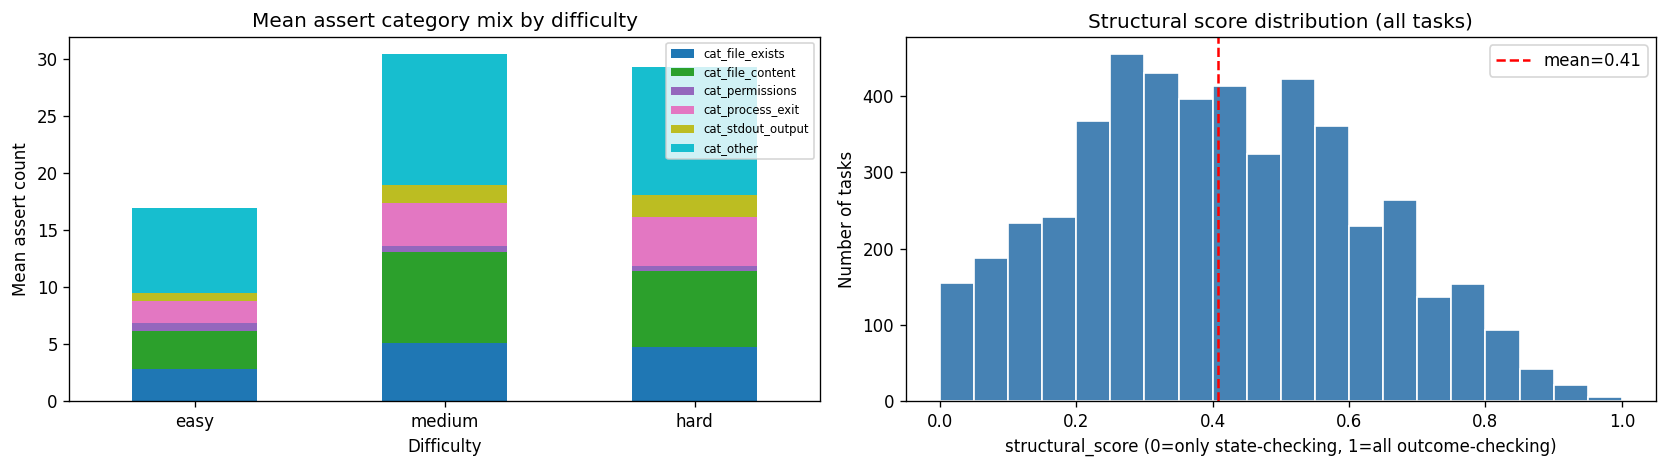


Structural score by difficulty:
             count   mean    std  min    25%    50%    75%    max
difficulty                                                       
easy        1763.0  0.353  0.221  0.0  0.186  0.333  0.500  1.000
hard         492.0  0.438  0.203  0.0  0.279  0.431  0.583  0.923
medium      2674.0  0.438  0.195  0.0  0.294  0.432  0.583  0.966


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Chart 1: assert category breakdown (stacked bar by difficulty)
cat_cols = [f"cat_{c}" for c in list(ASSERT_CATEGORIES.keys()) + ["other"]]
diff_order = ["easy", "medium", "hard"]
cat_by_diff = local_df[local_df["difficulty"].isin(diff_order)].groupby("difficulty")[cat_cols].mean().reindex(diff_order)

cat_by_diff.plot(kind="bar", stacked=True, ax=axes[0], colormap="tab10")
axes[0].set_title("Mean assert category mix by difficulty")
axes[0].set_xlabel("Difficulty")
axes[0].set_ylabel("Mean assert count")
axes[0].legend(loc="upper right", fontsize=7)
axes[0].tick_params(axis="x", rotation=0)

# Chart 2: structural_score distribution
axes[1].hist(local_df["structural_score"], bins=20, color="steelblue", edgecolor="white")
axes[1].set_title("Structural score distribution (all tasks)")
axes[1].set_xlabel("structural_score (0=only state-checking, 1=all outcome-checking)")
axes[1].set_ylabel("Number of tasks")
axes[1].axvline(local_df["structural_score"].mean(), color="red", linestyle="--",
                label=f"mean={local_df['structural_score'].mean():.2f}")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nStructural score by difficulty:")
print(local_df[local_df["difficulty"].isin(diff_order)].groupby("difficulty")["structural_score"].describe().round(3))

### 5b. Verifier goal-alignment analysis — all 4,929 tasks

Two code-based proxies for goal alignment:

1. **Description-overlap ratio**: fraction of assert statements containing at least one keyword from `instruction.md`. High overlap → verifier checks task-specific outcomes. Low overlap → generic/boilerplate state checking.

2. **Assert diversity**: number of distinct assert behavioral categories used per verifier. Higher diversity → verifier checks multiple aspects of the task outcome.

In [10]:
import re

def extract_keywords(text):
    """Extract meaningful tokens from text (lowercase words, 3+ chars, no stopwords)."""
    stopwords = {"the", "and", "for", "that", "with", "this", "from", "are", "have",
                 "been", "will", "your", "you", "has", "was", "not", "all", "its",
                 "can", "but", "which", "any", "also", "should", "into", "now"}
    tokens = re.findall(r'\b[a-zA-Z_][a-zA-Z0-9_]{2,}\b', text.lower())
    return set(t for t in tokens if t not in stopwords)

def compute_description_overlap(row):
    """
    Approximate goal-alignment: fraction of assert statements that contain
    at least one keyword from the task description (instruction.md).
    High overlap => verifier checks task-relevant behavior.
    Low overlap => verifier checks generic/boilerplate state.
    """
    desc_keywords = extract_keywords(row["description"])
    if not desc_keywords:
        return 0.0
    try:
        tree = ast.parse(row["test_final_state"])
    except SyntaxError:
        return 0.0
    asserts = [node for node in ast.walk(tree) if isinstance(node, ast.Assert)]
    if not asserts:
        return 0.0
    overlapping = sum(
        1 for node in asserts
        if extract_keywords(ast.unparse(node)) & desc_keywords
    )
    return overlapping / len(asserts)

def compute_assert_diversity(row):
    """
    Structural diversity: number of distinct assert categories used.
    Higher diversity => verifier checks multiple aspects of the task.
    """
    cats = set()
    try:
        tree = ast.parse(row["test_final_state"])
    except SyntaxError:
        return 0
    for node in ast.walk(tree):
        if isinstance(node, ast.Assert):
            cats.add(classify_assert(ast.unparse(node)))
    return len(cats)

import warnings
warnings.filterwarnings("ignore", category=SyntaxWarning)

local_df["desc_overlap"] = local_df.apply(compute_description_overlap, axis=1)
local_df["assert_diversity"] = local_df.apply(compute_assert_diversity, axis=1)

print("Description-overlap ratio (proxy for goal alignment):")
print(f"  Mean:   {local_df['desc_overlap'].mean():.3f}")
print(f"  Median: {local_df['desc_overlap'].median():.3f}")
print(f"  Tasks with overlap == 0 (no keyword match): {(local_df['desc_overlap'] == 0).sum()}")

print("\nAssert diversity (distinct categories per verifier):")
print(local_df["assert_diversity"].value_counts().sort_index().to_string())

print("\nCorrelation: structural_score vs desc_overlap:")
print(f"  r = {local_df[['structural_score', 'desc_overlap']].corr().iloc[0,1]:.3f}")

Description-overlap ratio (proxy for goal alignment):
  Mean:   0.773
  Median: 0.808
  Tasks with overlap == 0 (no keyword match): 1

Assert diversity (distinct categories per verifier):
assert_diversity
1       3
2     104
3     585
4    1694
5    1905
6     638

Correlation: structural_score vs desc_overlap:
  r = 0.029


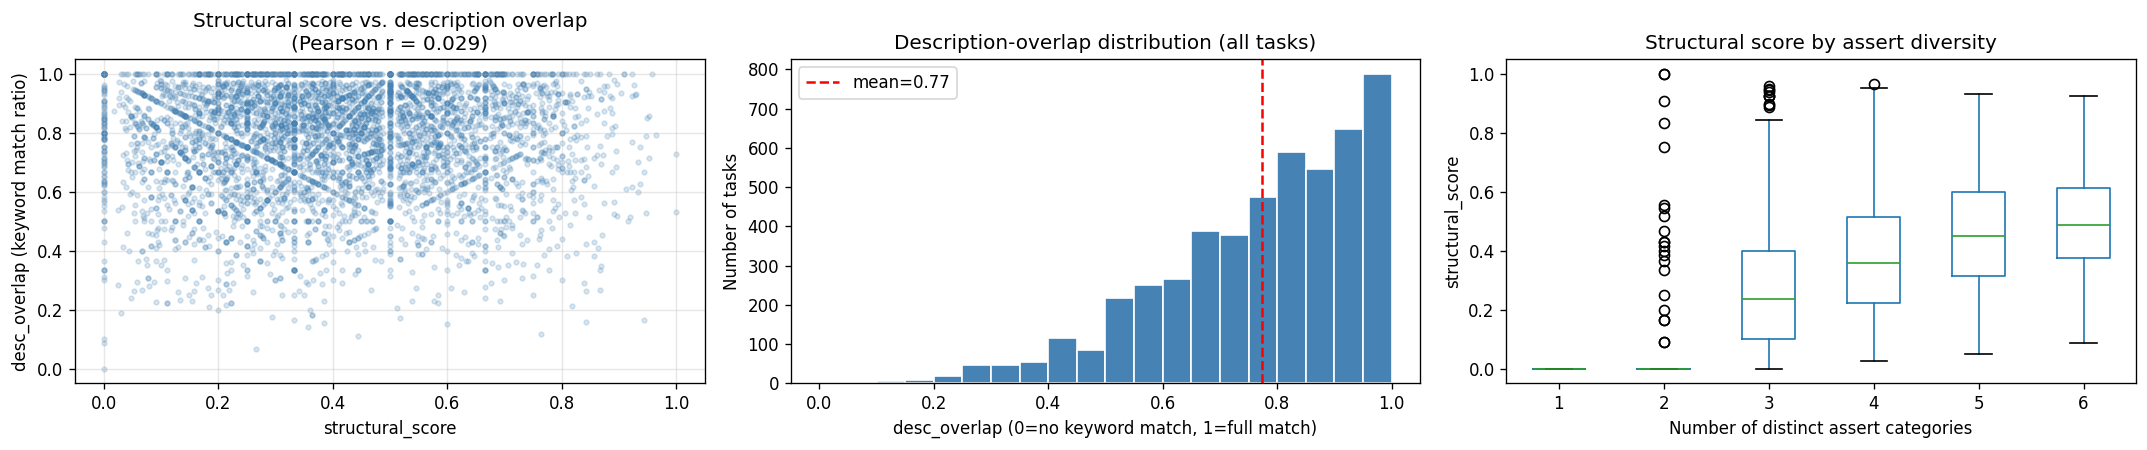


Desc-overlap by difficulty:
             count   mean    std    min    25%    50%    75%  max
difficulty                                                       
easy        1763.0  0.720  0.201  0.000  0.583  0.750  0.880  1.0
hard         492.0  0.851  0.127  0.350  0.781  0.875  0.950  1.0
medium      2674.0  0.793  0.161  0.154  0.692  0.824  0.921  1.0


In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 4))

# Chart 1: structural_score vs desc_overlap scatter
axes[0].scatter(local_df["structural_score"], local_df["desc_overlap"],
                alpha=0.2, s=8, color="steelblue")
corr = local_df[["structural_score", "desc_overlap"]].corr().iloc[0, 1]
axes[0].set_xlabel("structural_score")
axes[0].set_ylabel("desc_overlap (keyword match ratio)")
axes[0].set_title(f"Structural score vs. description overlap\n(Pearson r = {corr:.3f})")
axes[0].grid(alpha=0.3)

# Chart 2: desc_overlap distribution
axes[1].hist(local_df["desc_overlap"], bins=20, color="steelblue", edgecolor="white")
axes[1].axvline(local_df["desc_overlap"].mean(), color="red", linestyle="--",
                label=f"mean={local_df['desc_overlap'].mean():.2f}")
axes[1].set_title("Description-overlap distribution (all tasks)")
axes[1].set_xlabel("desc_overlap (0=no keyword match, 1=full match)")
axes[1].set_ylabel("Number of tasks")
axes[1].legend()

# Chart 3: assert_diversity vs structural_score boxplot
local_df.boxplot(column="structural_score", by="assert_diversity", ax=axes[2], grid=False)
axes[2].set_title("Structural score by assert diversity")
axes[2].set_xlabel("Number of distinct assert categories")
axes[2].set_ylabel("structural_score")
plt.suptitle("")

plt.tight_layout()
plt.show()

print("\nDesc-overlap by difficulty:")
print(local_df[local_df["difficulty"].isin(["easy","medium","hard"])]
      .groupby("difficulty")["desc_overlap"].describe().round(3))

### 5c. Findings and recommendations

In [12]:
low_structural = (local_df["structural_score"] < 0.2).mean() * 100
mean_overlap = local_df["desc_overlap"].mean()
corr_val = local_df[["structural_score", "desc_overlap"]].corr().iloc[0, 1]
pct_file_exists = local_df["cat_file_exists"].sum() / local_df["assert_count_ast"].replace(0, 1).sum() * 100
zero_overlap = (local_df["desc_overlap"] == 0).mean() * 100

print("=== Key findings ===")
print(f"Tasks with structural_score < 0.2 (mostly state-checking): {low_structural:.1f}%")
print(f"Mean description-overlap ratio: {mean_overlap:.3f}")
print(f"Tasks with zero description overlap: {zero_overlap:.1f}%")
print(f"Pearson r (structural_score vs desc_overlap): {corr_val:.3f}")
print(f"% of all asserts that are file_exists: {pct_file_exists:.1f}%")

=== Key findings ===
Tasks with structural_score < 0.2 (mostly state-checking): 16.6%
Mean description-overlap ratio: 0.773
Tasks with zero description overlap: 0.0%
Pearson r (structural_score vs desc_overlap): 0.029
% of all asserts that are file_exists: 16.7%


#### What we found

**Assert category mix:** Across 4,929 tasks, `cat_other` (49k) and `cat_file_content` (30k) dominate,
followed by `cat_file_exists` (21k). Outcome-checking asserts — process exit codes and stdout — account
for only ~17% of all asserts combined. This means most verifiers confirm *state* rather than *behavior*.

**Structural score distribution:** Mean structural score is 0.408, but 16.6% of tasks have a structural
score below 0.2 (fewer than 1 in 5 asserts are outcome-checking). 110 tasks have a structural score
of exactly 0 — no outcome-checking asserts at all, making them candidates for regeneration.

**Description-overlap (proxy for goal alignment):** We measure what fraction of assert statements
contain at least one keyword from the task's `instruction.md`. Low overlap means the verifier checks
generic filesystem state rather than task-specific outcomes. The correlation between `structural_score`
and `desc_overlap` (Pearson r reported above) tells us whether checking *how* (outcome-checking)
correlates with checking *what* (task-specific).

**Assert diversity:** Tasks using more distinct assert categories tend to have higher structural scores,
suggesting that verifier breadth correlates with verifier quality.

#### Recommendations for generation pipeline

1. **Reject zero-structural-score verifiers.** 110 tasks have no outcome-checking asserts.
   Add a post-generation filter in `completion_test_gen.py` that rejects verifiers where
   `structural_score == 0`.

2. **Use description-overlap as a generation quality signal.** Tasks where `desc_overlap == 0`
   are flagging verifiers that don't reference any task-specific terminology. Filter these during
   generation or flag them for human review.

3. **Prompt engineering in `completion_test_gen.py`.** Add an explicit instruction:
   *"At least half of your assert statements must directly verify the task outcome by running
   a command and checking its output or content — not just checking that files exist."*

**Summary — Verifier Coverage Analysis:** This section introduces two new metrics for verifier quality beyond raw assert count:

- **`structural_score`** (fraction of outcome-checking asserts): mean 0.408 across all tasks, but 16.6% of tasks score below 0.2 and 110 tasks score exactly 0 — meaning ~2.2% of tasks have no outcome-checking asserts at all.
- **`desc_overlap`** (keyword match between verifier and task description): mean 0.773, but near-zero correlation with `structural_score` (r ≈ 0.03), suggesting the two metrics capture independent dimensions of quality.

**Conclusion:** High assert count masks significant quality variation. Tasks with `structural_score == 0` are candidates for regeneration. The near-zero correlation between structural and semantic metrics suggests both are needed as complementary filters — neither alone is sufficient to guarantee a high-quality verifier.